<a href="https://colab.research.google.com/github/aman-5137/half_plasma/blob/main/_4_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Binary Classification

In [146]:
import pandas as pd
df = pd.read_csv("/content/sample_data/Book3.csv")
df.head()

,Age,Has_Insurance
0,19,0
1,22,1
2,25,0
3,28,0
4,31,1


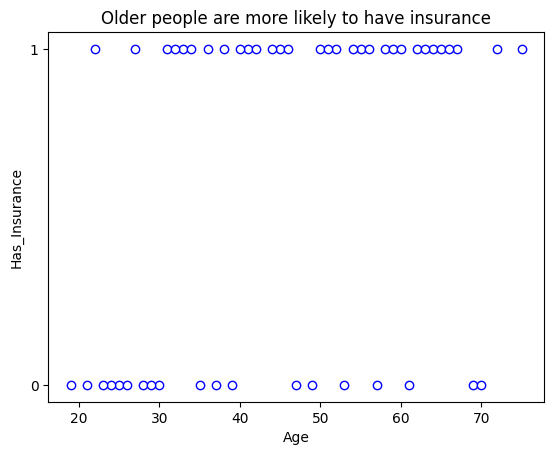

In [147]:
import matplotlib.pyplot as plt

plt.scatter(df.Age, df.Has_Insurance, color='#fff', edgecolors='b')
plt.xlabel('Age')
plt.ylabel('Has_Insurance')
plt.title('Older people are more likely to have insurance')
plt.yticks([0,1])
plt.show()

In [148]:
from sklearn.model_selection import train_test_split

X= df[['Age']]
y=df['Has_Insurance']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=3)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((10, 1), (40, 1), (10,), (40,))

In [149]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [150]:
ages = pd.DataFrame({"Age":[10,20,30, 45, 70,60]})
model.predict(ages)

array([0, 0, 0, 1, 1, 1])

In [151]:
model.predict_proba(ages)

array([[9.99999953e-01, 4.73384387e-08],
       [9.99931353e-01, 6.86473761e-05],
       [9.09453046e-01, 9.05469536e-02],
       [1.81830928e-04, 9.99818169e-01],
       [2.27062813e-12, 1.00000000e+00],
       [3.29296435e-09, 9.99999997e-01]])

In [152]:
model.coef_, model.intercept_

(array([[0.72794842]]), array([-24.14542733]))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


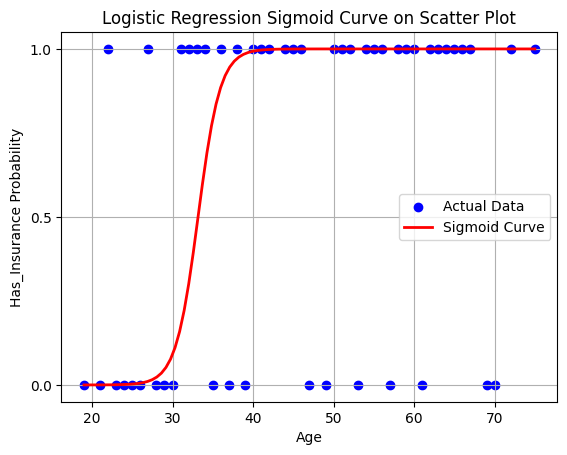

In [153]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the original scatter data
plt.scatter(df.Age, df.Has_Insurance, color='blue', edgecolors='b', label='Actual Data')

# Generate a range of ages for the sigmoid curve
loss = model.predict_proba(X)
X_new = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Predict probabilities for the new age range
y_proba = model.predict_proba(X_new)[:, 1]

# Plot the sigmoid curve
plt.plot(X_new, y_proba, color='red', linewidth=2, label='Sigmoid Curve')

plt.xlabel('Age')
plt.ylabel('Has_Insurance Probability')
plt.title('Logistic Regression Sigmoid Curve on Scatter Plot')
plt.yticks([0, 0.5, 1])
plt.grid(True)
plt.legend()
plt.show()

In [154]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))
def prediction_function(age):
  z = model.coef_[0] [0] * age + model.intercept_[0] # z = mx + b
  y = sigmoid(z)
  return y
prediction_function(70)

0.9999999999977294

In [155]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.38      0.44        16
           1       0.66      0.79      0.72        24

    accuracy                           0.62        40
   macro avg       0.60      0.58      0.58        40
weighted avg       0.61      0.62      0.61        40

